# Soc5044 Computational Sociology W8 Practicum - Classification (Decision Tree)

These teaching materials are adpated from the official website of [*Scikit Learn*](https://scikit-learn.org/stable/index.html) for the course "Soc5044 Computational Sociology" lectured at the sociology department of National Taiwan University by Dr. Chen-Shuo Hong.

In particular, this file references the following web pages:
- "1.10. Decision Trees", Section 1 Supervised Learning. https://scikit-learn.org/stable/modules/tree.html.

Editor: Jun-Wei Liu (b09902009@ntu.edu.tw)

---

# Scikit Learn Setup

Scikit-learn is a powerful and easy-to-use Python library for machine learning. It provides simple and efficient tools for data mining and data analysis, and is built on NumPy, SciPy, and matplotlib. Scikit-learn supports various supervised and unsupervised learning algorithms, including regression, classification, clustering, and dimensionality reduction.

In [1]:
!pip install scikit-learn numpy

Defaulting to user installation because normal site-packages is not writeable


# Decision Trees

## Introduction

Decision trees are a popular and intuitive method for classification and regression tasks in machine learning. They work by recursively splitting the data into subsets based on the value of input features, creating a tree-like structure of decisions. Each internal node of the tree represents a decision based on a feature, each branch represents the outcome of that decision, and each leaf node represents a final prediction or classification.

In social research, decision trees can be used to identify patterns and relationships between variables, make predictions, and classify individuals or groups based on their characteristics. For example, decision trees can help researchers understand the factors that influence voting behavior, predict the likelihood of an individual experiencing a particular social outcome, or classify individuals into different socioeconomic groups.

## Quick Start 

Let's start with a simple dataset where each sample has 2 features 'x1' and 'x2', and a binary output 'y' (i.e., 0 or 1).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Generate a simple dataset with 2 features and binary output (use your own dataset in your research)
X, y = make_classification(n_samples=100,
                           n_features=2, n_informative=2, n_redundant=0,
                           random_state=42)
print(X)


[[ 0.55942643  2.38869353]
 [ 1.31217492 -0.7173148 ]
 [-1.5598485  -1.92487377]
 [-2.2813861  -0.1368559 ]
 [ 1.56070438 -0.42795824]
 [-0.80804463  1.19664076]
 [-0.27062383 -2.25553963]
 [ 0.480502    0.54914434]
 [-1.20757158 -1.26898369]
 [ 0.25415746 -1.79532002]
 [ 2.59123946  0.24472415]
 [ 0.07123641  0.49429823]
 [-1.17762637 -1.20592943]
 [ 0.93343952  0.68811892]
 [ 1.65214494 -0.35885569]
 [-1.40735658 -1.56826626]
 [ 1.02255619 -1.08324727]
 [-0.81680628 -0.6795874 ]
 [ 1.50575249 -0.38919817]
 [-2.17105282 -0.04862909]
 [ 0.71479373 -1.42922002]
 [-0.15013844 -0.11708689]
 [-1.4117586  -1.5332749 ]
 [-2.58590856 -0.40925706]
 [ 0.82600732 -1.05383855]
 [-0.07133524  0.08896214]
 [ 0.6273745  -1.32933233]
 [ 1.65882246 -0.43131517]
 [ 1.2798899   1.25896077]
 [ 0.25058844  0.13979096]
 [-0.05319823  1.85605469]
 [-2.05832072 -2.52343407]
 [-2.02632079  0.06194498]
 [-1.65830375 -1.57127256]
 [ 1.28008347  1.28938375]
 [ 0.96423311  0.55600276]
 [-1.87653774  0.23085877]
 

To 'fit' a decision tree to the data, follow these steps:

1. **Initialize the Decision Tree Classifier**: Create an instance of the `DecisionTreeClassifier` class from the scikit-learn library. You can specify parameters such as `max_depth` to control the maximum depth of the tree and `random_state` for reproducibility.

2. **Fit the Decision Tree to the Data**: Use the `fit` method of the classifier instance to train the decision tree on your dataset. This method takes the input features (`X`) and the target labels (`y`) as arguments. The decision tree learns the patterns in the data by recursively splitting the dataset based on the values of the input features.

3. **Trained Model**: After fitting, the decision tree is trained and can be used to make predictions on new data. The tree structure represents the learned decision rules that can classify or predict outcomes based on the input features.


In [4]:
# Train a decision tree classifier with a maximum depth of 4
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=4, random_state=42)

Great! Now that the decision tree has fit the data, let's visualize the tree structure.

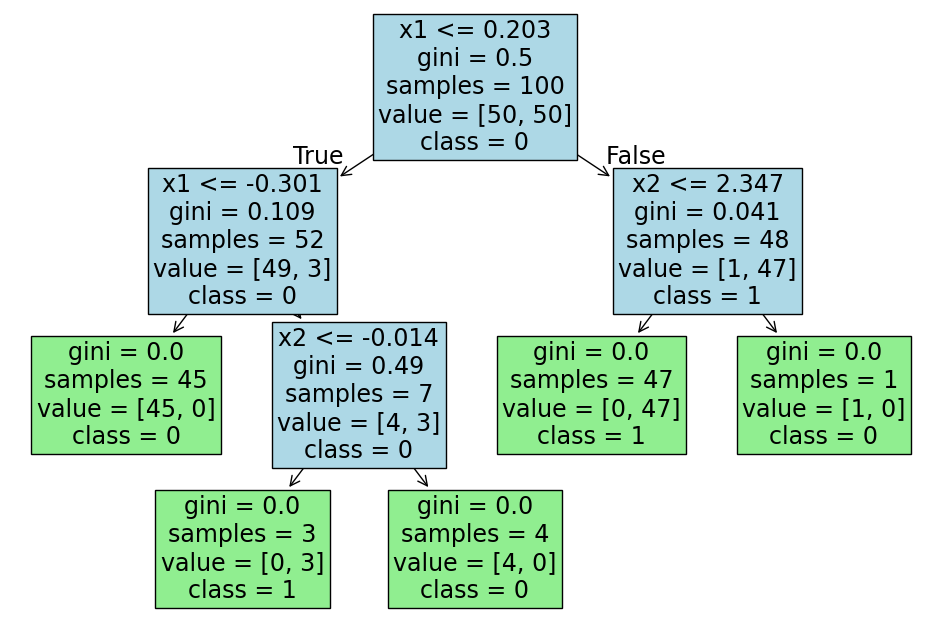

In [14]:
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=['x1', 'x2'], class_names=['0', '1'])

# Customize colors for nodes and leaves
ax = plt.gca()
for node in ax.get_children():
    if isinstance(node, plt.Text):
        text = node.get_text()
        if 'x1' in node.get_text() or 'x2' in node.get_text():
            node.set_bbox(dict(facecolor='lightblue', edgecolor='black'))  # Color for nodes
        elif 'class' in node.get_text():
            node.set_bbox(dict(facecolor='lightgreen', edgecolor='black'))  # Color for leaves

plt.show()

Each *node* (in blue color) in the decision tree represents a decision based on one of the features. For example, a node might check if 'x1' is less than a certain value. The decision at each node then splits the data into two groups: one group that satisfies the condition and another group that does not.

By keep splitting the data in groups, the path reaches *leaf nodes* (in green color), which are the terminal nodes of the tree, meaning they do not split further.
Each leaf node represents a final classification outcome (either class 0 or class 1 in this case).


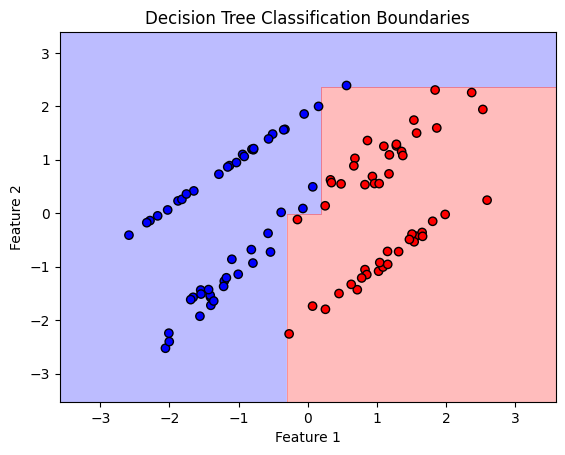

In [15]:
# Plot the data and decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.bwr)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Classification Boundaries')
plt.show()

On the two dimensional feature space, we can understand this decision tree in another prespective.

First of all, We see each decision as a line across the space. For example, the decision at the root node 'x1 <= 0.203' represents a vertical line 'x1 = 0.203'. All samples to the left of this line will follow one branch of class 0, and all samples to the right will follow the other branch of class 1. Similarly, the condition "x2 > 2.347" represents a horizontal line at "x2 = 2.347". These lines divide the feature space into regions classified as either 0 or 1.

## Example with Taiwan Youth Project (TYP) dataset

One type of research question that a decision tree can answer is: *What characteristics define a group of people with a particular social outcome?*

For example, *what are the characteristics of people who has early marriages*?

Let's use the dataset [台灣青少年成長歷程研究：TYP2017調查(成人合併樣本第三波)](https://srda.sinica.edu.tw/search/metadata/detail/D00188) and explore early marriages decisions with decision tree.

- Target population: "2000年為台北市、台北縣以及宜蘭縣的國中學生".
- Survey period: 2017/9 to 2018/3.
- Sample size: 2551.

> 伊慶春（2021）。台灣青少年成長歷程研究：TYP2017調查(成人合併樣本第三波)（公共版）（D00188）【原始數據】取自中央研究院人文社會科學研究中心調查研究專題中心學術調查研究資料庫。https://doi.org/10.6141/TW-SRDA-D00188-1

In [7]:
import pandas as pd

# Load CSV file
file_path = "../data/typ2017-adult-wave3/TYP2017_Jan2021.csv"
df = pd.read_csv(file_path, encoding="big5", low_memory=False)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2551 entries, 0 to 2550
Columns: 976 entries, m3sschool to m3ssu6003
dtypes: int64(905), object(71)
memory usage: 19.0+ MB
None


We use the following variables:

Y:
- `m3s001020`: 你認為你是否早婚?
    - 結婚時的年紀: `m3s001011` (你第一次結婚的時間是?) - `m3sbirth_year` (出生年)

X:
- `m3ssex`: 性別
- `m3sedulevel`: 最高教育程度
- 兄弟姊妹數量
    - `m3s002001-004`: 請問你有幾個兄弟姊妹？從未有婚姻經驗者
    - `m3s022001-004`: 請問你有幾個兄弟姊妹？有婚姻經驗者

In [ ]:
# Compute Y (early marriage)
df["early_marriage"] = df["m3s001020"].replace({1: 1, 2: 0, 0: pd.NA, 7: pd.NA, 8: pd.NA, 9: pd.NA})
df["m3s001011"] = df["m3s001011"].replace({0: pd.NA, 997: pd.NA, 998: pd.NA, 999: pd.NA})
df["m3sbirth_year"] = df["m3sbirth_year"].replace({0: pd.NA, 997: pd.NA, 998: pd.NA, 999: pd.NA})
df["marriage_age"] = df["m3s001011"] - df["m3sbirth_year"]

# Select X (features)
df["male"] = df["m3ssex"].replace({1: 1, 2: 0, 7: pd.NA, 8: pd.NA, 9: pd.NA}) 
df["edulevel"] = df["m3sedulevel"].replace({97: pd.NA, 98: pd.NA, 99: pd.NA})
df["num_siblings"] = df[["m3s002001", "m3s002002", "m3s002003", "m3s002004",
                         "m3s022001", "m3s022002", "m3s022003", "m3s022004"]].replace({7: pd.NA, 8: pd.NA, 9: pd.NA}).sum(axis=1, min_count=1)

# Select X and y
X = df[["male", "edulevel", "num_siblings"]]
y = df["early_marriage"]

# Ensure correct data types (convert to numeric if necessary)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

(2551, 3) (2551,)


Drop the rows with missing values.

In [25]:
def drop_nan_rows_in_both(X, Y):
    # Combine the DataFrames horizontally to easily identify rows with NaNs in either
    combined = pd.concat([X, Y], axis=1)

    # Drop rows where any value is NaN
    combined_cleaned = combined.dropna()

    # Split the cleaned DataFrame back into X and Y
    X_cleaned = combined_cleaned.iloc[:, :X.shape[1]]  # Select columns corresponding to X
    Y_cleaned = combined_cleaned.iloc[:, X.shape[1]:]  # Select columns corresponding to Y

    # Reset the index of the cleaned DataFrames
    X_cleaned = X_cleaned.reset_index(drop=True)
    Y_cleaned = Y_cleaned.reset_index(drop=True)

    return X_cleaned, Y_cleaned

X, y = drop_nan_rows_in_both(X, y)

assert X.shape[0] == y.shape[0]
print(f"Sample size after dropping missing values: {X.shape[0]}")

Sample size after dropping missing values: 1006


Because 'early marriage' is a self-reported perception, we begin by comparing the average age at first marriage between individuals who identify their marriage as early and those who do not.

In [32]:
early_marriage = df.loc[df["m3s001020"] == 1, "marriage_age"]
not_early_marriage = df.loc[df["m3s001020"] == 2, "marriage_age"]
print(f"認為自己早婚者，結婚時年齡 (N={early_marriage.shape[0]})： {early_marriage.mean():.2f} ({early_marriage.std():.2f})")
print(f"不認為自己早婚者，結婚時年齡 (N={not_early_marriage.shape[0]})： {not_early_marriage.mean():.2f} ({not_early_marriage.std():.2f})")

認為自己早婚者，結婚時年齡 (N=203)： 25.42 (2.84)
不認為自己早婚者，結婚時年齡 (N=805)： 28.93 (2.36)


Then we can train our decision tree!  We need to specify the maximum depth of the tree.

In [43]:
max_depth = 6

In [44]:
from sklearn.tree import DecisionTreeClassifier 

clf = DecisionTreeClassifier(max_depth=max_depth, random_state=1026)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=6, random_state=1026)

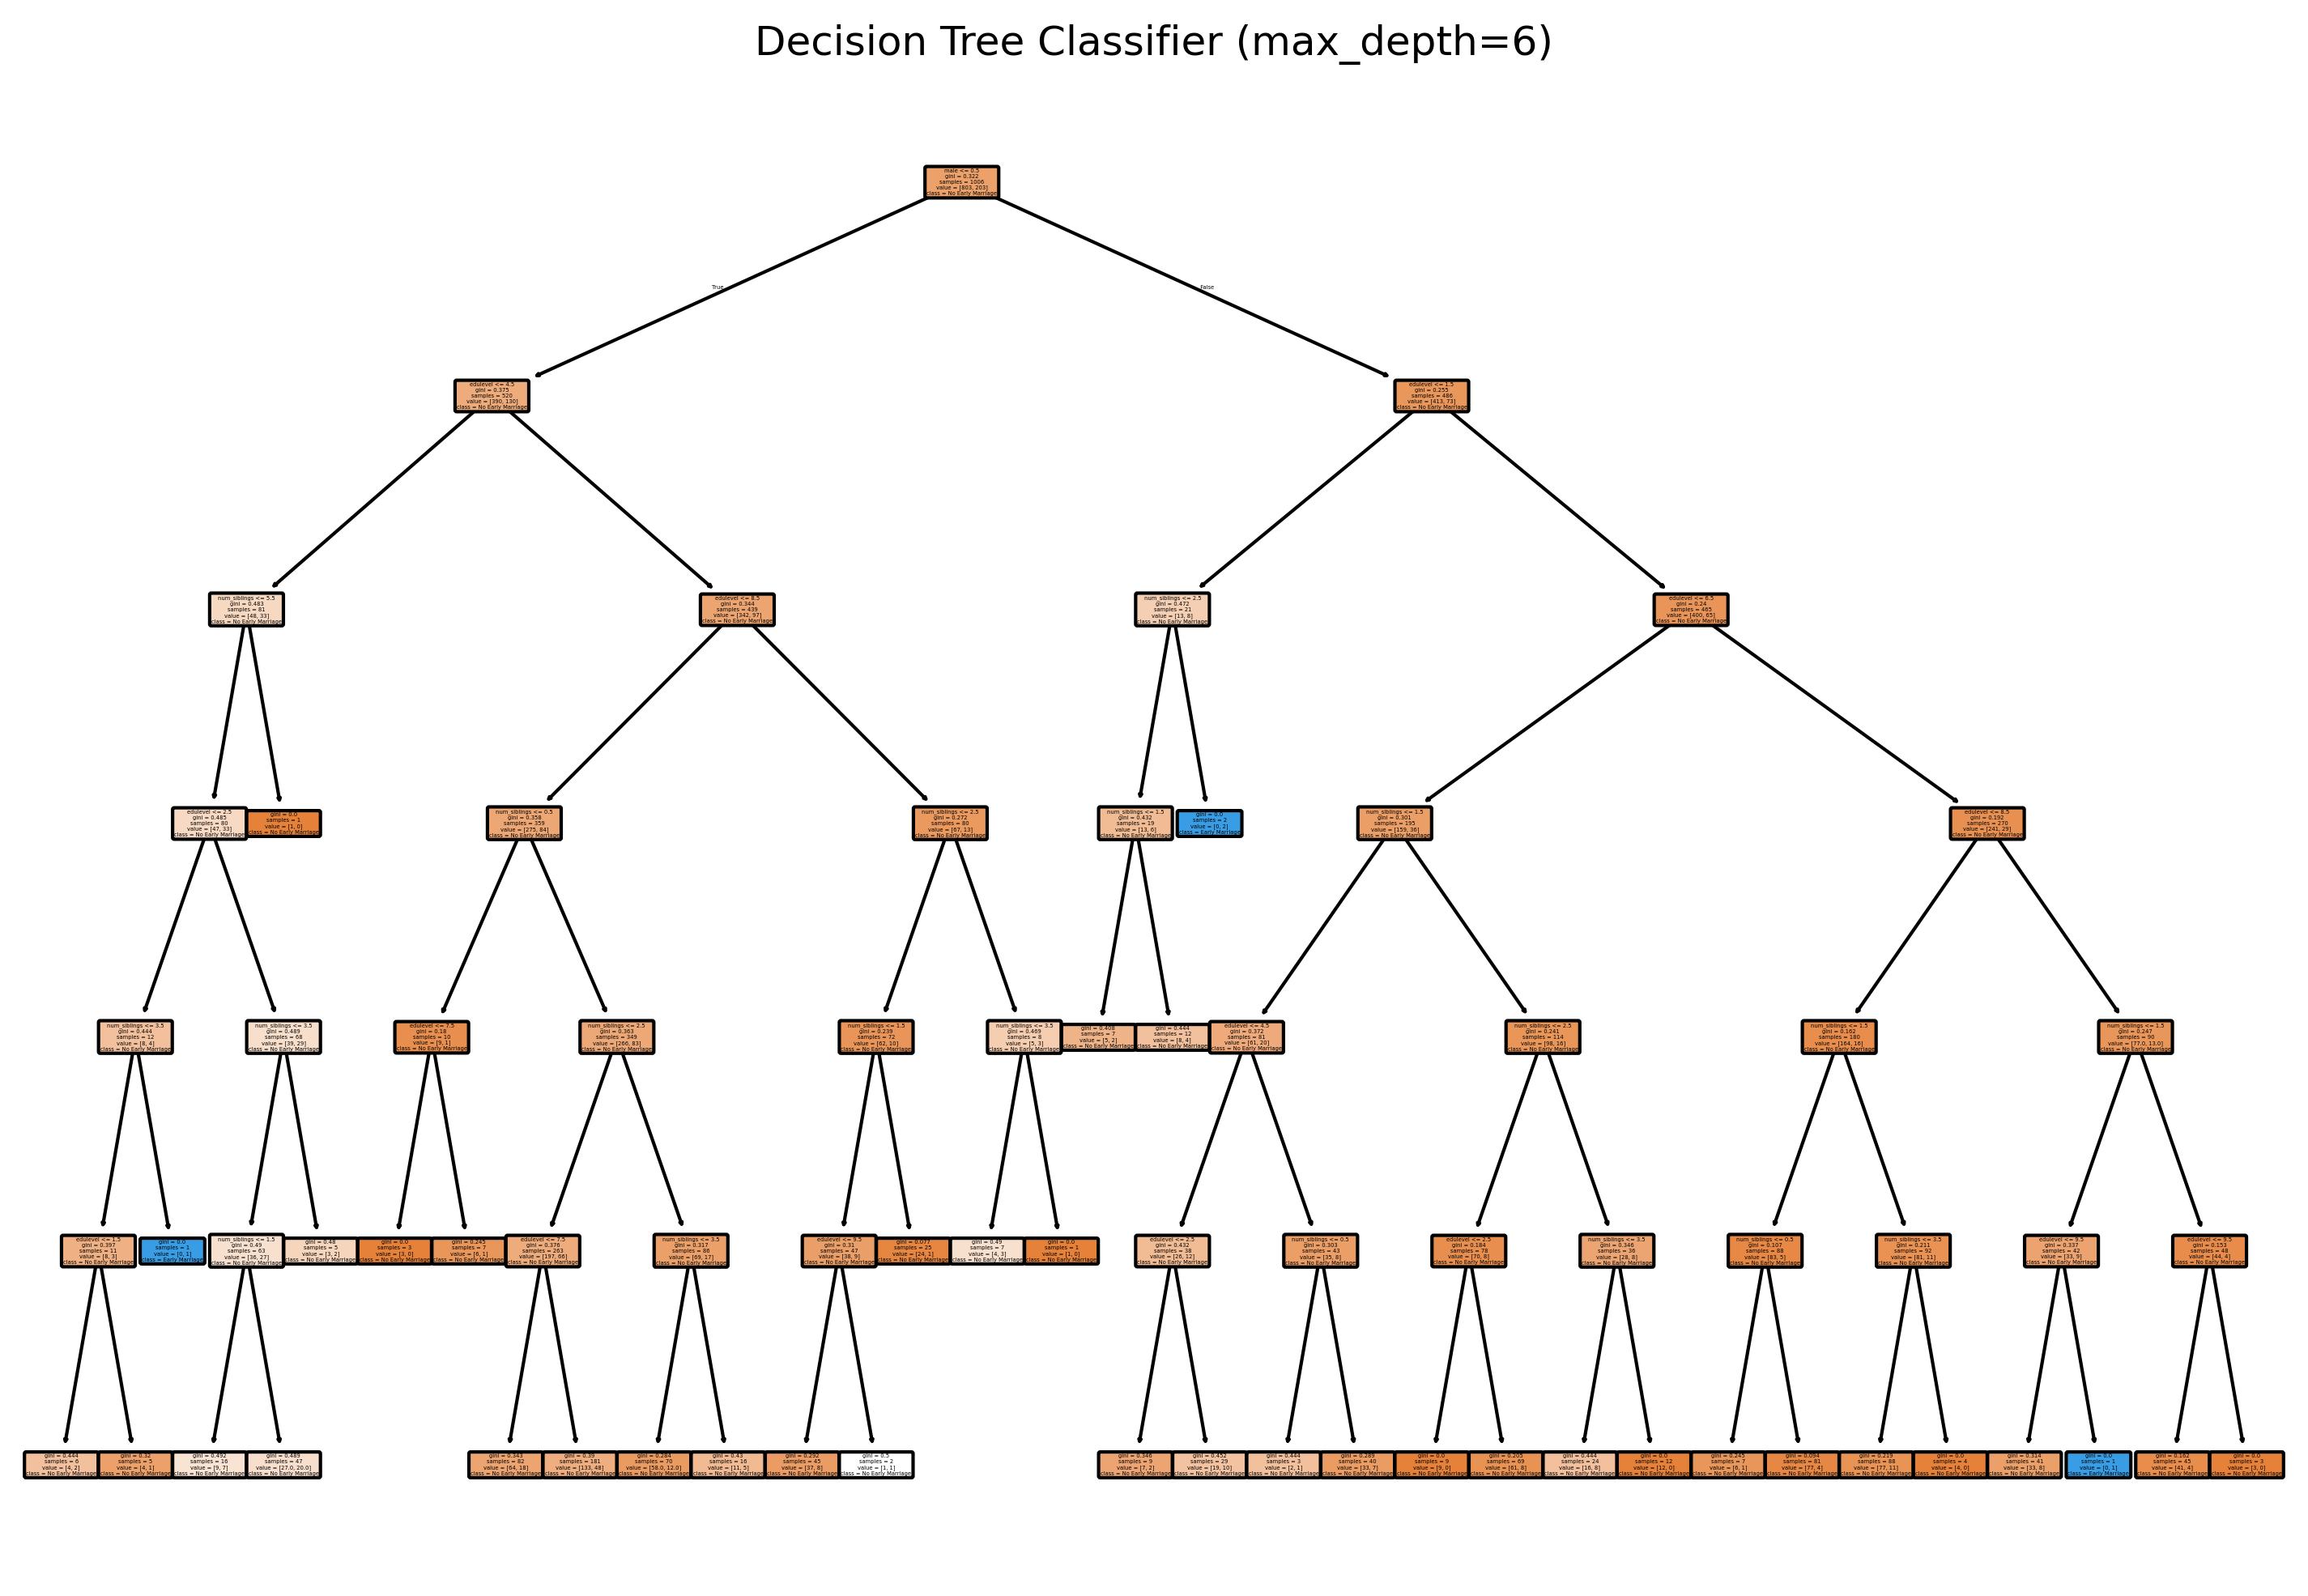

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(12, 8), dpi=300)
plot_tree(clf, filled=True, feature_names=["male", "edulevel", "num_siblings"], class_names=["No Early Marriage", "Early Marriage"], rounded=True)
plt.title(f"Decision Tree Classifier (max_depth={max_depth})")
plt.show()

List all the combinations of "decisions" that lead to early marriages (the blue leaf nodes).

In [46]:
import re

# Get the decision tree structure
tree = clf.tree_
feature_names = X.columns

# Function to recursively find all paths from root to leaves where y = 1
def find_paths(tree, feature_names, node=0, path=None, paths=None):
    if path is None:
        path = []
    if paths is None:
        paths = []

    # If we are at a leaf node
    if tree.feature[node] == -2:  # leaf node is indicated by -2
        # Check if this leaf node corresponds and only corresponds to y = 1 (early marriage)
        if tree.value[node][0, 1] > 0 and tree.value[node][0, 0] == 0: 
            paths.append([path, tree.weighted_n_node_samples[node]])  # Append the current path if it leads to y = 1
        return paths

    # Get the feature index and threshold
    feature_index = tree.feature[node]
    threshold = tree.threshold[node]

    # Build the condition for the current split
    feature_name = feature_names[feature_index]
    condition = f"{feature_name} <= {threshold:.2f}"

    # Go down the left branch (True branch)
    paths = find_paths(tree, feature_names, tree.children_left[node], path + [condition], paths)
    # Go down the right branch (False branch)
    paths = find_paths(tree, feature_names, tree.children_right[node], path + [f"not {condition}"], paths)

    return paths

# Find all paths that lead to y = 1 (early marriage)
paths_to_early_marriage = find_paths(tree, feature_names)

# Function to combine conditions
def combine_conditions(conditions):
    # Split the conditions into those with "<=" and ">" for each feature
    less_than_conditions = []
    greater_than_conditions = []
    
    for condition in conditions:
        feature, operator, value = re.match(r"([a-zA-Z_]+) ([<=|>|=]+) ([\d\.]+)", condition).groups()
        
        if operator == "<=":
            less_than_conditions.append((feature, float(value)))
        elif operator == ">":
            greater_than_conditions.append((feature, float(value)))
    
    if less_than_conditions and greater_than_conditions:
        min_value = min(less_than_conditions, key=lambda x: x[1])[1]
        max_value = max(greater_than_conditions, key=lambda x: x[1])[1]
        return f"{max_value} < {feature} <= {min_value}"
    elif less_than_conditions:
        min_value = min(less_than_conditions, key=lambda x: x[1])[1]
        return f"{feature} <= {min_value}"
    elif greater_than_conditions:
        max_value = max(greater_than_conditions, key=lambda x: x[1])[1]
        return f"{feature} > {max_value}"

# Function to process paths
def process_path_conditions(paths):
    processed_paths = []
    
    for path, v in paths:
        # 1. Remove 'not' and negate the conditions
        tmp = list()
        for p in path:
            if 'not' in p:
                p = p.replace('not ', '')
                if '<=' in p:
                    p = p.replace('<=', '>')
                elif '>' in p:
                    p = p.replace('>', '<=')
            tmp.append(p)
        path = tmp
        
        # 2. Combine conditions with the same feature
        combined_conditions = {}
        for condition in path:
            feature, operator, value = re.match(r"([a-zA-Z_]+) ([<=|>|=]+) ([\d\.]+)", condition).groups()
            if feature not in combined_conditions:
                combined_conditions[feature] = []
            combined_conditions[feature].append(condition)
        
        # Combine the final conditions for this path
        final_conditions = [combine_conditions(conditions) for _, conditions in combined_conditions.items()]
        
        # Combine the final conditions for the path using "AND"
        processed_paths.append([" AND ".join(final_conditions), int(v)])
    
    return processed_paths

# Display the processed paths
print("Groups of people that have early marriages:")
for i, (path, v) in enumerate(process_path_conditions(paths_to_early_marriage)):
    # print(f"group {i} | decisions={path} (group size={v})")
    print(f"group {i} | decisions={path}")

Groups of people that have early marriages:
group 0 | decisions=male <= 0.5 AND edulevel <= 2.5 AND 3.5 < num_siblings <= 5.5
group 1 | decisions=male > 0.5 AND edulevel <= 1.5 AND num_siblings > 2.5
group 2 | decisions=male > 0.5 AND edulevel > 9.5 AND num_siblings <= 1.5


The result shows that there are 3 groups of people that tend to have early marriages.
1. Female with low education level and have 4 or 5 siblings
2. Male with low education level and have more than 3 siblings
3. Male with Phd education level and have no more than 1 siblings